In [57]:
from PIL import Image
import numpy as np
import math
import matplotlib.pyplot as plt

In [16]:
gambar = Image.open("images/astronaut.png").convert("L")
matriksblur = np.array(gambar)

In [81]:
def tetangga4(x, y, matriks):
    atas = int(matriks[y-1][x])
    bawah = int(matriks[y+1][x])
    kiri = int(matriks[y][x-1])
    kanan = int(matriks[y][x+1])
    return atas + bawah + kiri + kanan
def tetangga8(x, y, matriks):
    atas_kiri = int(matriks[y-1][x-1])
    atas = int(matriks[y-1][x])
    atas_kanan = int(matriks[y-1][x+1])
    kiri = int(matriks[y][x-1])
    kanan = int(matriks[y][x+1])
    bawah_kiri = int(matriks[y+1][x-1])
    bawah = int(matriks[y+1][x])
    bawah_kanan = int(matriks[y+1][x+1])
    return atas_kiri + atas + atas_kanan + kiri + kanan + bawah_kiri + bawah + bawah_kanan

def bluring(x, y):
    tengah = int(matriksblur[y][x])
    mean_matriks = (tengah + tetangga8(x, y, matriksblur)) / 9
    tengah = mean_matriks
    return tengah

In [98]:
alpha = [0.5, 1, 1.5, 2]
def lap_sharp4 (x, y, matriks):
    tengah = int(matriks[y][x])
    perubahan = 4 * tengah - tetangga4(x, y, matriks)
    hasil = []
    for i in alpha:
        perubahan_baru = perubahan * i
        piksel_baru = tengah + perubahan_baru
        piksel_baru = max(0, min(255, piksel_baru))
        hasil.append(piksel_baru)
    return hasil

def lap_sharp8 (x, y, matriks):
    tengah = int(matriks[y][x])
    perubahan = 8 * tengah - tetangga8(x, y, matriks)
    hasil = []
    for i in alpha:
        perubahan_baru = perubahan * i
        piksel_baru = tengah + perubahan_baru
        piksel_baru = max(0, min(255, piksel_baru))
        hasil.append(piksel_baru)
    return hasil

In [79]:
hasil_gambar = matriksblur.copy()

In [82]:
for i in range(1, len(matriksblur) - 1):
    for j in range(1, len(matriksblur[i]) - 1):
        hasil = bluring(j, i)
        hasil_gambar[i][j] = hasil

In [83]:
selisih = np.abs(matriksblur.astype(int) - hasil_gambar.astype(int))

print("Selisih maksimum :", selisih.max())
print("Rata-rata selisih :", selisih.mean())
print("Jumlah pixel berubah :", np.count_nonzero(selisih))

Selisih maksimum : 144
Rata-rata selisih : 3.6675453186035156
Jumlah pixel berubah : 191030


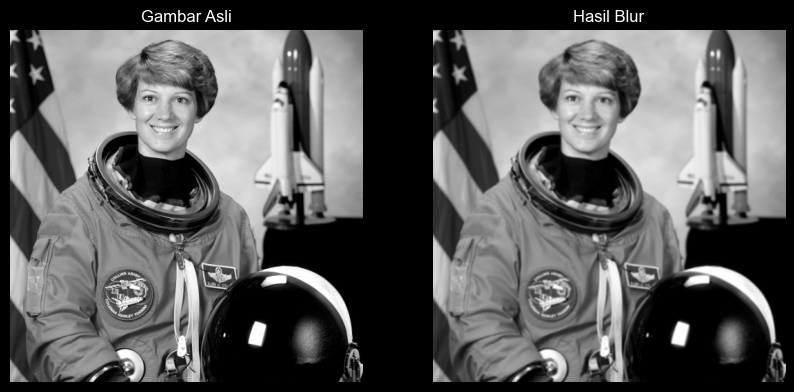

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil_gambar, cmap="gray", vmin=0, vmax=255)
plt.title("Hasil Blur")
plt.axis("off")

plt.show()

In [85]:
hasil_laplacian4 = [
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy()
]
hasil_laplacian8 = [
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy()
]

In [102]:
for i in range(1, len(hasil_gambar) - 1):
    for j in range(1, len(hasil_gambar[i]) - 1):
        hasil = lap_sharp4(j, i, hasil_gambar)
        for k in range(len(alpha)):
            hasil_laplacian4[k][i][j] = hasil[k]

for i in range(1, len(hasil_gambar) - 1):
    for j in range(1, len(hasil_gambar[i]) - 1):
        hasil = lap_sharp8(j, i, hasil_gambar)
        for k in range(len(alpha)):
            hasil_laplacian8[k][i][j] = hasil[k]

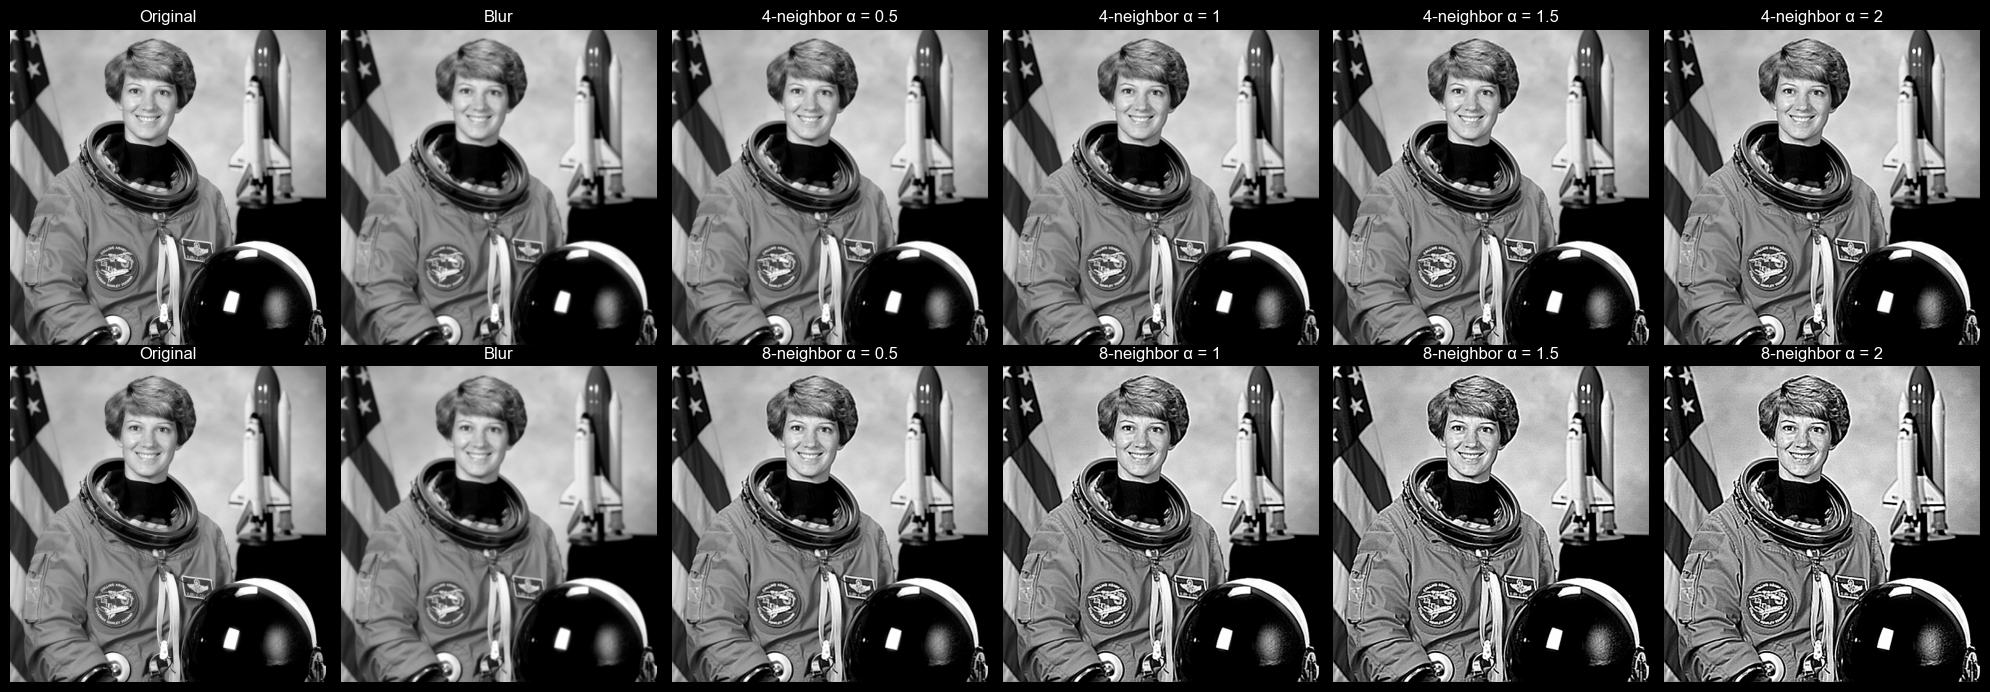

In [106]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

axes[0, 0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(hasil_gambar, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Blur")
axes[0, 1].axis("off")

for k in range(len(alpha)):
    axes[0, k + 2].imshow(
        hasil_laplacian4[k],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[0, k + 2].set_title(f"4-neighbor α = {alpha[k]}")
    axes[0, k + 2].axis("off")

axes[1, 0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")


axes[1, 1].imshow(hasil_gambar, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("Blur")
axes[1, 1].axis("off")

for k in range(len(alpha)):
    axes[1, k + 2].imshow(
        hasil_laplacian8[k],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[1, k + 2].set_title(f"8-neighbor α = {alpha[k]}")
    axes[1, k + 2].axis("off")

plt.tight_layout()
plt.show()